## 2.1 理论计算题
1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输
入为 x，隐藏层没有激活函数（即线性激活），表达为 h = W1x + b1，
输出层为 o = W2h + b2 。请通过代数推导证明，该网络等价于一个单
层神经网络，并写出等价后的权重矩阵 W′ 和偏置向量 b
′ 。
2. 激活函数性质分析：写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推
导它们的导数 Sigmoid′
(x) 和 tanh′
(x) 与其函数自身的关系。

### 1. 非线性激活函数的重要性

**已知：**
*   隐藏层：$h = W_1x + b_1$
*   输出层：$o = W_2h + b_2$
*   其中 $W_1, W_2$ 为权重矩阵，$b_1, b_2$ 为偏置向量。

**推导过程：**
将隐藏层的表达式代入输出层中：
$$o = W_2(W_1x + b_1) + b_2$$

利用矩阵乘法的分配律展开：
$$o = W_2W_1x + W_2b_1 + b_2$$

由于矩阵乘法满足结合律，我们可以令 $W' = W_2W_1$，同时令 $b' = W_2b_1 + b_2$，则原式可以化简为：
$$o = W'x + b'$$

**结论：**
经过代数推导，整个网络的输入输出关系可以表示为 $o = W'x + b'$，这完全是一个线性的仿射变换。也就是说，无论隐藏层有多少个神经元，只要没有引入非线性的激活函数，该网络在数学上就**等价于一个单层线性神经网络**。

等价后的权重矩阵和偏置向量分别为：
*   **等价权重矩阵：** $W' = W_2W_1$
*   **等价偏置向量：** $b' = W_2b_1 + b_2$

---

### 2. 激活函数性质分析

#### (1) Sigmoid 函数
**数学表达式：**
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**导数推导：**
利用商的求导法则 $(\frac{u}{v})' = \frac{u'v - uv'}{v^2}$，其中 $u=1$, $v=1+e^{-x}$：
$$\sigma'(x) = \frac{0 \cdot (1 + e^{-x}) - 1 \cdot (-e^{-x})}{(1 + e^{-x})^2} = \frac{e^{-x}}{(1 + e^{-x})^2}$$

为了将其表示为函数自身 $\sigma(x)$ 的关系，我们对分子进行代数变形，将 $e^{-x}$ 写成 $(1 + e^{-x}) - 1$：
$$\sigma'(x) = \frac{(1 + e^{-x}) - 1}{(1 + e^{-x})^2} = \frac{1 + e^{-x}}{(1 + e^{-x})^2} - \frac{1}{(1 + e^{-x})^2}$$
$$\sigma'(x) = \frac{1}{1 + e^{-x}} - \left(\frac{1}{1 + e^{-x}}\right)^2$$

提取公因式 $\sigma(x)$，得：
$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

**Sigmoid 导数与自身的关系：**
$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

---

#### (2) tanh 函数
**数学表达式：**
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

**导数推导：**
同样利用商的求导法则，令 $u = e^x - e^{-x}$，$v = e^x + e^{-x}$，则 $u' = e^x + e^{-x}$，$v' = e^x - e^{-x}$：
$$\tanh'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}$$
$$\tanh'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

利用平方差公式 $a^2 - b^2 = (a-b)(a+b)$ 展开：
$$\tanh'(x) = 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2$$

注意到后半部分正是 $\tanh(x)$ 的平方，因此：
$$\tanh'(x) = 1 - \tanh^2(x)$$

**tanh 导数与自身的关系：**
$$\tanh'(x) = 1 - \tanh^2(x)$$

---



In [2]:
## 2.2 编程题
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ==========================================
# 1. 数据加载与预处理
# ==========================================
def load_data(batch_size=256):
    # 下载 Fashion-MNIST 数据集
    trans = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
    
    train_iter = DataLoader(train_dataset, batch_size, shuffle=True)
    test_iter = DataLoader(test_dataset, batch_size, shuffle=False)
    return train_iter, test_iter

# ==========================================
# 2. 模型参数初始化
# ==========================================
# Fashion-MNIST 图像大小为 28x28 = 784，共 10 个类别
num_inputs = 784
num_hiddens = 256
num_outputs = 10

# 使用正态分布随机初始化权重，偏置初始化为 0
# requires_grad=False 因为我们完全手动计算和更新梯度，不需要 PyTorch 的 autograd
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=False)
b1 = torch.zeros(num_hiddens, requires_grad=False)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=False)
b2 = torch.zeros(num_outputs, requires_grad=False)

# ==========================================
# 3. 激活函数与损失函数实现
# ==========================================
def relu(X):
    """实现 ReLU 激活函数: max(0, x)"""
    return torch.max(X, torch.zeros_like(X))

def softmax(X):
    """实现数值稳定的 Softmax 函数"""
    # 对每个样本减去其最大值，防止 exp 溢出
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

def cross_entropy_loss(y_hat, y):
    """
    实现 Softmax + 交叉熵损失函数
    y_hat: (batch_size, num_classes) 模型预测的 Softmax 概率
    y: (batch_size,) 真实标签索引
    """
    # 使用 gather 提取真实标签对应的预测概率
    # y_hat.shape[0] 是 batch_size
    prob = y_hat.gather(1, y.view(-1, 1))
    # 计算交叉熵，并取均值
    return -torch.log(prob).mean()

# ==========================================
# 4. 前向传播与反向传播（手动梯度计算）
# ==========================================
def forward_and_backward(X, y):
    """
    前向传播计算损失，并手动计算所有参数的梯度
    """
    global W1, b1, W2, b2
    
    # --- 前向传播 ---
    # 展平图像输入: (batch, 1, 28, 28) -> (batch, 784)
    X = X.reshape((-1, num_inputs))
    
    Z1 = torch.matmul(X, W1) + b1
    H = relu(Z1)
    Z2 = torch.matmul(H, W2) + b2
    y_hat = softmax(Z2)
    
    loss = cross_entropy_loss(y_hat, y)
    
    # --- 手动反向传播求梯度 ---
    batch_size = X.shape[0]
    
    # 1. Softmax + 交叉熵的联合梯度: (y_hat - y_one_hot) / batch_size
    # 构造 one-hot 标签
    y_one_hot = torch.zeros_like(y_hat).scatter_(1, y.view(-1, 1), 1.0)
    dZ2 = (y_hat - y_one_hot) / batch_size
    
    # 2. 输出层 W2, b2 的梯度
    grad_W2 = torch.matmul(H.t(), dZ2)
    grad_b2 = dZ2.sum(dim=0)
    
    # 3. 反传到隐藏层
    dH = torch.matmul(dZ2, W2.t())
    # 4. ReLU 的梯度
    dZ1 = dH * (Z1 > 0).float() # Z1 > 0 的位置梯度为 1，否则为 0
    
    # 5. 隐藏层 W1, b1 的梯度
    grad_W1 = torch.matmul(X.t(), dZ1)
    grad_b1 = dZ1.sum(dim=0)
    
    return loss, grad_W1, grad_b1, grad_W2, grad_b2

# ==========================================
# 5. 小批量随机梯度下降 (SGD) 参数更新
# ==========================================
def sgd(params, grads, lr):
    """手动实现 SGD 优化器"""
    for param, grad in zip(params, grads):
        # 使用 torch.no_grad() 确保原地进行加减操作时不会构建计算图
        with torch.no_grad():
            param -= lr * grad

# ==========================================
# 6. 模型评估与训练循环
# ==========================================
def accuracy(y_hat, y):
    """计算准确率"""
    preds = y_hat.argmax(dim=1)
    return (preds == y).float().mean().item()

def train(num_epochs=10, lr=0.1, batch_size=256):
    train_iter, test_iter = load_data(batch_size)
    
    params = [W1, b1, W2, b2]
    
    for epoch in range(num_epochs):
        train_loss_sum, train_acc_sum, n = 0.0, 0.0, 0
        
        for X, y in train_iter:
            # 前向传播 + 手动反向传播
            loss, grad_W1, grad_b1, grad_W2, grad_b2 = forward_and_backward(X, y)
            
            # 手动更新参数
            sgd([W1, b1, W2, b2], [grad_W1, grad_b1, grad_W2, grad_b2], lr)
            
            # 统计指标
            with torch.no_grad():
                X_flat = X.reshape((-1, num_inputs))
                y_hat = softmax(torch.matmul(relu(torch.matmul(X_flat, W1) + b1), W2) + b2)
                train_loss_sum += loss.item() * y.shape[0]
                train_acc_sum += accuracy(y_hat, y) * y.shape[0]
                n += y.shape[0]
                
        # 测试集评估
        test_acc_sum, test_n = 0.0, 0
        for X_test, y_test in test_iter:
            with torch.no_grad():
                X_test_flat = X_test.reshape((-1, num_inputs))
                y_test_hat = softmax(torch.matmul(relu(torch.matmul(X_test_flat, W1) + b1), W2) + b2)
                test_acc_sum += accuracy(y_test_hat, y_test) * y_test.shape[0]
                test_n += y_test.shape[0]
                
        print(f'Epoch {epoch + 1}/{num_epochs} | '
              f'Train Loss: {train_loss_sum/n:.4f} | '
              f'Train Acc: {train_acc_sum/n:.3f} | '
              f'Test Acc: {test_acc_sum/test_n:.3f}')

# 运行训练
if __name__ == '__main__':
    train(num_epochs=10, lr=0.1)


Epoch 1/10 | Train Loss: 1.0402 | Train Acc: 0.655 | Test Acc: 0.718
Epoch 2/10 | Train Loss: 0.6004 | Train Acc: 0.802 | Test Acc: 0.763
Epoch 3/10 | Train Loss: 0.5202 | Train Acc: 0.830 | Test Acc: 0.797
Epoch 4/10 | Train Loss: 0.4839 | Train Acc: 0.842 | Test Acc: 0.824
Epoch 5/10 | Train Loss: 0.4560 | Train Acc: 0.852 | Test Acc: 0.824
Epoch 6/10 | Train Loss: 0.4363 | Train Acc: 0.860 | Test Acc: 0.817
Epoch 7/10 | Train Loss: 0.4183 | Train Acc: 0.865 | Test Acc: 0.840
Epoch 8/10 | Train Loss: 0.4052 | Train Acc: 0.869 | Test Acc: 0.849
Epoch 9/10 | Train Loss: 0.3909 | Train Acc: 0.873 | Test Acc: 0.840
Epoch 10/10 | Train Loss: 0.3849 | Train Acc: 0.877 | Test Acc: 0.849


## 3.1 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差
很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这
一现象？
2. K 折交叉验证：阐述 K 折交叉验证（K-fold Cross-Validation）的具
体实施算法步骤。

### 1. 过拟合与欠拟合

#### (1) 训练误差与泛化误差的区别
*   **训练误差**：指模型在**训练数据集**上计算得出的误差。它反映了模型对训练数据中样本的拟合程度，也就是模型“学习”已有数据的能力。
*   **泛化误差**：指模型在**未见过的、独立的新数据集**（即测试集或真实应用场景中的数据）上的期望误差。它反映了模型对未知数据的预测和泛化能力。

**核心区别**：训练误差是“事后”评估，只能说明模型对见过的数据掌握得好；泛化误差是“事前”评估，才是衡量模型在实际应用中真正表现的指标。深度学习的核心挑战之一，就是如何缩小训练误差与泛化误差之间的差距。

#### (2) 模型所处的状态
当一个模型的训练误差极低，但泛化误差很高时，说明模型把训练数据学得“太好了”，甚至把训练数据中的噪声和偶然特征也当成了普遍规律，导致面对新数据时预测失败。此时模型处于**过拟合**状态。

#### (3) 如何通过控制模型复杂度来缓解过拟合
过拟合的根本原因通常是“模型容量过大，超过了数据本身的复杂度”。因此，缓解过拟合的核心思路是**降低模型复杂度**或**增加数据量/数据多样性**。具体控制模型复杂度的方法包括：

1.  **降低模型结构复杂度**：
    *   减少网络的层数（变浅）。
    *   减少每层的隐藏单元/神经元数量（变窄）。
2.  **正则化**：
    *   **L1/L2 正则化**：在损失函数中加入权重矩阵的惩罚项（如 L2 正则化限制权重过大），迫使模型使用更小、更分散的权重，从而降低模型拟合复杂函数的能力。
    *   **Dropout（随机失活）**：在训练过程中随机让部分神经元停止工作，这可以看作是每次训练了一个子网络，相当于变相降低了模型容量，同时起到了模型集成的效果。
3.  **提前停止**：
    *   在训练过程中监控验证集的误差。当训练误差还在继续下降，但验证集误差开始上升时，及时停止训练，防止模型过度拟合训练集。
4.  **限制训练轮数**：
    *   避免让模型有充足的时间去死记硬背训练数据的每一个细节。

---

### 2. K 折交叉验证

在数据量有限的情况下，如果仅仅划分一次训练集和验证集，验证结果可能会受到数据划分随机性的严重影响。K 折交叉验证通过多次划分和评估，能够更客观地评估模型的泛化能力。

#### K 折交叉验证的具体实施算法步骤：

**前提准备**：
假设我们有一个包含 $N$ 个样本的数据集 $D$，我们设定一个整数 $K$（通常取 5 或 10），将模型训练和评估的超参数配置固定。

**算法步骤**：

1.  **数据打乱与划分**：
    将数据集 $D$ 中的样本随机打乱，然后尽量均匀地划分为 $K$ 个大小相近的、互不相交的子集，记为 $D_1, D_2, \dots, D_K$。

2.  **循环训练与验证**：
    对于 $i = 1, 2, \dots, K$，执行以下操作：
    *   **确定验证集**：将第 $i$ 个子集 $D_i$ 作为验证集。
    *   **确定训练集**：将其余的 $K-1$ 个子集合并作为训练集，即 $D_{train} = D \setminus D_i$。
    *   **模型训练**：使用当前训练集 $D_{train}$ 从头训练模型。
    *   **模型评估**：在当前验证集 $D_i$ 上评估训练好的模型，记录下评估指标（如准确率、损失值等），记为 $E_i$。

3.  **计算平均性能**：
    经过 $K$ 轮循环后，我们得到了 $K$ 个评估结果 $E_1, E_2, \dots, E_K$。计算这 $K$ 个结果的算术平均值作为模型在该配置下的最终性能评估：
    $$E_{avg} = \frac{1}{K} \sum_{i=1}^{K} E_i$$

4.  **模型最终重训练（可选但推荐）**：
    在确定了最佳超参数后，通常会用整个数据集 $D$ 重新训练一次模型，以充分利用所有数据，得到最终部署的模型。

**K 折交叉验证的优势**：
它确保了每个样本都有机会被划入验证集恰好一次，并且划入训练集 $K-1$ 次。这样得出的评估结果对数据划分方式不再敏感，比单次划分的留出法更稳定、更可靠。

开始对比实验...
[无正则化] 训练完成。最终 Train Loss: 0.2819, Test Loss: 0.8508
[有权重衰减] 训练完成。最终 Train Loss: 0.3527, Test Loss: 0.8985
[有 Dropout] 训练完成。最终 Train Loss: 0.3085, Test Loss: 0.7936


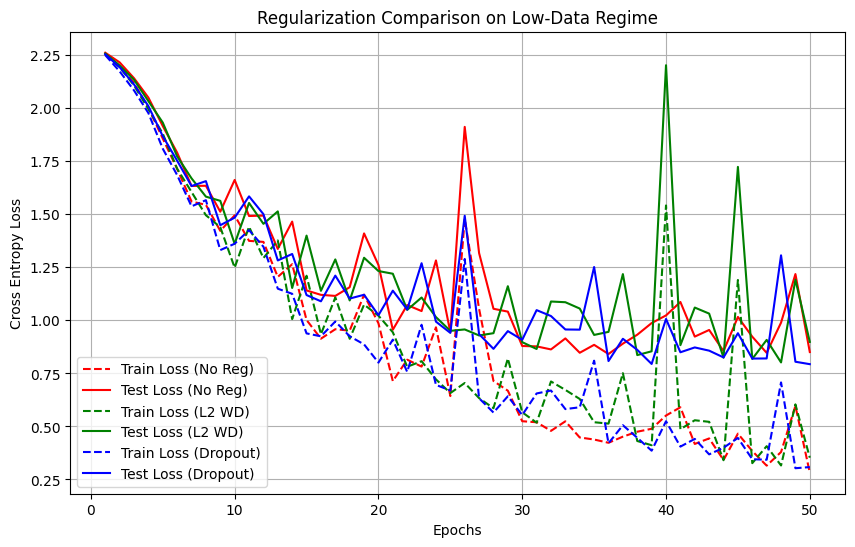

In [3]:
#3.2 编程题
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据加载（极小样本集以诱导过拟合）
# ==========================================
def load_data(batch_size=64):
    trans = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
    
    # 仅取前 200 个样本作为训练集，故意制造数据不足的情况以引发过拟合
    train_subset = Subset(train_dataset, range(200))
    
    train_iter = DataLoader(train_subset, batch_size, shuffle=True)
    test_iter = DataLoader(test_dataset, batch_size, shuffle=False)
    return train_iter, test_iter

# ==========================================
# 2. 模型参数初始化
# ==========================================
num_inputs = 784
num_hiddens = 512  # 使用较宽的隐藏层加剧过拟合
num_outputs = 10

def init_params():
    W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=False)
    b1 = torch.zeros(num_hiddens, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=False)
    b2 = torch.zeros(num_outputs, requires_grad=False)
    return [W1, b1, W2, b2]

# ==========================================
# 3. 激活函数、Dropout 与 损失函数
# ==========================================
def relu(X):
    return torch.max(X, torch.zeros_like(X))

def dropout_layer(X, dropout, is_training=True):
    """从零实现 Dropout 层"""
    assert 0 <= dropout <= 1
    if not is_training or dropout == 0.0:
        return X
    if dropout == 1.0:
        return torch.zeros_like(X)
    
    # 生成随机掩码: 伯努利分布，概率为 1-dropout
    mask = (torch.rand(X.shape) > dropout).float()
    # 缩放：除以 (1 - dropout) 保持期望值不变 (Inverted Dropout)
    return (X * mask) / (1.0 - dropout)

def softmax(X):
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)
    return X_exp / X_exp.sum(dim=1, keepdim=True)

def cross_entropy_loss(y_hat, y):
    prob = y_hat.gather(1, y.view(-1, 1))
    return -torch.log(prob).mean()

# ==========================================
# 4. 前向传播与手动反向传播
# ==========================================
def forward(X, params, dropout_rate, is_training):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, num_inputs))
    
    Z1 = torch.matmul(X, W1) + b1
    H = relu(Z1)
    # 在隐藏层后应用 Dropout
    H_drop = dropout_layer(H, dropout_rate, is_training)
    
    Z2 = torch.matmul(H_drop, W2) + b2
    y_hat = softmax(Z2)
    return y_hat, H, H_drop

def backward(X, y, y_hat, H, H_drop, params, dropout_rate):
    W1, b1, W2, b2 = params
    batch_size = X.shape[0]
    X = X.reshape((-1, num_inputs))
    
    # Softmax + 交叉熵梯度
    y_one_hot = torch.zeros_like(y_hat).scatter_(1, y.view(-1, 1), 1.0)
    dZ2 = (y_hat - y_one_hot) / batch_size
    
    # 输出层梯度
    grad_W2 = torch.matmul(H_drop.t(), dZ2)
    grad_b2 = dZ2.sum(dim=0)
    
    # 反传到隐藏层，需要乘以 Dropout 的 mask
    dH_drop = torch.matmul(dZ2, W2.t())
    # Dropout 梯度反传：只有未被 drop 的神经元有梯度，且需除以 (1-p)
    dH = dH_drop * (H_drop != 0).float() / (1.0 - dropout_rate)
    
    # ReLU 梯度
    dZ1 = dH * (H > 0).float()
    
    # 隐藏层梯度
    grad_W1 = torch.matmul(X.t(), dZ1)
    grad_b1 = dZ1.sum(dim=0)
    
    return [grad_W1, grad_b1, grad_W2, grad_b2]

# ==========================================
# 5. 带权重衰减的 SGD 优化器
# ==========================================
def sgd(params, grads, lr, wd):
    """手动实现带权重衰减的 SGD"""
    for i, (param, grad) in enumerate(zip(params, grads)):
        with torch.no_grad():
            # 偏置项 (索引为1,3) 通常不进行权重衰减
            if i in [1, 3]: 
                param -= lr * grad
            else:
                # 权重衰减: W = W - lr * (grad + wd * W) 等价于 W = (1 - lr*wd) * W - lr * grad
                param *= (1.0 - lr * wd)
                param -= lr * grad

# ==========================================
# 6. 训练与评估模块
# ==========================================
def evaluate_loss_acc(data_iter, params, dropout_rate):
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for X, y in data_iter:
        with torch.no_grad():
            y_hat, _, _ = forward(X, params, dropout_rate, is_training=False)
            l = cross_entropy_loss(y_hat, y)
            loss_sum += l.item() * y.shape[0]
            acc_sum += (y_hat.argmax(dim=1) == y).float().mean().item() * y.shape[0]
            n += y.shape[0]
    return loss_sum / n, acc_sum / n

def train_experiment(config_name, lr=0.1, num_epochs=50, dropout_rate=0.0, wd=0.0):
    train_iter, test_iter = load_data()
    params = init_params()
    
    train_losses, test_losses = [], []
    
    for epoch in range(num_epochs):
        train_l_sum, n = 0.0, 0
        for X, y in train_iter:
            # 前向传播（训练时启用 Dropout）
            y_hat, H, H_drop = forward(X, params, dropout_rate, is_training=True)
            l = cross_entropy_loss(y_hat, y)
            
            # 手动反向传播
            grads = backward(X, y, y_hat, H, H_drop, params, dropout_rate)
            
            # 参数更新（传入 wd 启用权重衰减）
            sgd(params, grads, lr, wd)
            
            train_l_sum += l.item() * y.shape[0]
            n += y.shape[0]
            
        # 记录每个 epoch 结束后的误差
        train_loss, _ = evaluate_loss_acc(train_iter, params, dropout_rate)
        test_loss, _ = evaluate_loss_acc(test_iter, params, dropout_rate)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
    print(f"[{config_name}] 训练完成。最终 Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    return train_losses, test_losses

# ==========================================
# 7. 运行对比实验并绘制曲线
# ==========================================
if __name__ == '__main__':
    num_epochs = 50
    
    print("开始对比实验...")
    # 1. 无正则化
    train_loss_1, test_loss_1 = train_experiment("无正则化", dropout_rate=0.0, wd=0.0)
    # 2. 仅权重衰减
    train_loss_2, test_loss_2 = train_experiment("有权重衰减", dropout_rate=0.0, wd=0.003)
    # 3. 仅 Dropout
    train_loss_3, test_loss_3 = train_experiment("有 Dropout", dropout_rate=0.5, wd=0.0)

    # 绘制 Loss 曲线
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs, train_loss_1, 'r--', label='Train Loss (No Reg)')
    plt.plot(epochs, test_loss_1, 'r-', label='Test Loss (No Reg)')
    
    plt.plot(epochs, train_loss_2, 'g--', label='Train Loss (L2 WD)')
    plt.plot(epochs, test_loss_2, 'g-', label='Test Loss (L2 WD)')
    
    plt.plot(epochs, train_loss_3, 'b--', label='Train Loss (Dropout)')
    plt.plot(epochs, test_loss_3, 'b-', label='Test Loss (Dropout)')
    
    plt.title("Regularization Comparison on Low-Data Regime")
    plt.xlabel("Epochs")
    plt.ylabel("Cross Entropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


## 4.1 理论计算题
梯度消失与梯度爆炸：考虑一个 d 层的深层神经网络，其梯度计算包
含诸如多层矩阵连乘项 ∏d
i=
−
t
1 ∂h
i+1
∂h
i 。
1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯
度爆炸，什么情况下会导致梯度消失。
2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？


### 1. 梯度消失与梯度爆炸的量化分析

考虑一个 $d$ 层的深层神经网络，对于第 $l$ 层，其前向传播可以表示为：
$$z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]}$$
$$a^{[l]} = f^{[l]}(z^{[l]})$$
其中 $W^{[l]}$ 是权重矩阵，$a^{[l]}$ 是激活值，$f^{[l]}$ 是非线性激活函数。

根据链式法则，损失函数 $L$ 对第 $l$ 层权重 $W^{[l]}$ 的梯度包含连乘项：
$$\frac{\partial L}{\partial W^{[l]}} = \frac{\partial L}{\partial a^{[d]}} \prod_{k=l+1}^{d} \left( \underbrace{\text{diag}(f'^{[k]}(z^{[k]}))}_{\text{激活函数导数}} \cdot \underbrace{W^{[k]}}_{\text{权重矩阵}} \right) \cdot \text{（与当前层输入相关的项）}$$

为了量化分析，我们假设每层的权重矩阵为 $W$，激活函数导数为 $f'$，考虑连乘的核心部分：
$$\prod_{k=l+1}^{d} \left( f'^{[k]} \cdot W \right)$$

**量化分析结论：**

1.  **从矩阵乘法的角度（权重矩阵 $W$）**：
    连乘的矩阵乘积的范数取决于权重矩阵特征值的大小。假设 $W$ 的最大特征值为 $\lambda_{max}$，经过 $d-l$ 次连乘后，梯度范数的变化量级近似与 $\lambda_{max}^{d-l}$ 成正比。
    *   **梯度爆炸**：当 $\lambda_{max} > 1$ 时，随着层数加深（$d-l$ 增大），$\lambda_{max}^{d-l}$ 呈指数级增长，导致梯度范数急剧膨胀。
    *   **梯度消失**：当 $\lambda_{max} < 1$ 时，$\lambda_{max}^{d-l}$ 呈指数级衰减，导致梯度范数趋近于 0。

2.  **从激活函数导数的角度（$f'$）**：
    *   **Sigmoid 函数**：导数 $f'(x) = \sigma(x)(1-\sigma(x))$，其最大值为 $0.25$（在 $x=0$ 处取得）。这意味着即使权重矩阵的特征值恰好为 1，每次乘以激活导数，梯度也会至少缩小为原来的 $1/4$。经过几十层连乘后，$(0.25)^d \to 0$，必然导致梯度消失。
    *   **Tanh 函数**：导数 $f'(x) = 1 - \tanh^2(x)$，最大值为 $1$。但在大部分取值范围内，导数远小于 1，同样容易导致连乘项衰减。

**总结**：当连乘项 $\prod (f' \cdot \lambda_{max}) > 1$ 时发生梯度爆炸；当 $\prod (f' \cdot \lambda_{max}) < 1$ 时发生梯度消失。由于 Sigmoid 的 $f' \le 0.25$，它天生倾向于梯度消失。

---

### 2. 为什么 ReLU 能很大程度上缓解梯度消失？

ReLU（Rectified Linear Unit）的数学表达式为：
$$f(x) = \max(0, x)$$

其导数为：
$$f'(x) = \begin{cases} 1, & x > 0 \\ 0, & x \le 0 \end{cases}$$

ReLU 缓解梯度消失的原因主要有以下两点：

1.  **正区间导数恒为 1（核心原因）**：
    在 $x > 0$ 的区间内，ReLU 的导数是严格的常数 1。这意味着在反向传播的连乘链中，激活函数的导数项不再起到“衰减因子”的作用（即不再乘以小于 1 的数）。
    此时，梯度的连乘公式简化为：
    $$\prod_{k=l+1}^{d} \left( 1 \cdot W^{[k]} \right) = \prod_{k=l+1}^{d} W^{[k]}$$
    只要权重矩阵 $W$ 的初始化合理（例如使用 He 初始化，使其方差保持在 1 左右，即特征值接近 1），梯度就可以在多层网络中毫无衰减地传播，从而**从根本上打破了 Sigmoid/Tanh 因导数小于 1 而导致的指数级衰减**。

2.  **稀疏激活带来的线性化效应**：
    在 $x \le 0$ 时，ReLU 输出为 0，导数也为 0。虽然这会导致部分神经元“死亡”（Dead ReLU），但从网络整体来看，它使得网络在反向传播时相当于一个**稀疏的线性网络**（因为正区间是线性的）。对于存活的神经元，梯度是纯线性的，不存在 Sigmoid 那样的非线性饱和区（导数趋近于 0 的区域），因此不会在饱和区发生梯度停滞。

In [4]:
#4.2 编程题
import torch
import torch.nn as nn
import math

# ==========================================
# 1. 辅助函数定义
# ==========================================
def print_gradient_norms(model, title):
    """打印模型各层权重的梯度范数"""
    print(f"\n--- {title} ---")
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norm = param.grad.data.norm(2).item()
            print(f"Layer: {name:20s} | Grad Norm: {grad_norm:.6e}")
        elif 'weight' in name and param.grad is None:
            print(f"Layer: {name:20s} | Grad Norm: None (未计算)")

def build_deep_network(activation_fn, init_method, num_layers=20, hidden_dim=256):
    """构建深层全连接网络并应用指定的初始化"""
    layers = []
    # 输入层
    layers.append(nn.Linear(784, hidden_dim))
    layers.append(activation_fn)
    
    # 隐藏层
    for _ in range(num_layers - 1):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(activation_fn)
        
    # 输出层
    layers.append(nn.Linear(hidden_dim, 10))
    
    model = nn.Sequential(*layers)
    
    # 应用初始化策略
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_method(m)
            
    return model

def forward_and_backward(model):
    """前向传播和反向传播，返回是否发生 NaN"""
    # 生成随机输入和标签
    x = torch.randn(64, 784)
    y = torch.randint(0, 10, (64,))
    
    # 前向传播
    output = model(x)
    
    # 检查前向传播是否产生 NaN
    if torch.isnan(output).any():
        print("\n[警告] 前向传播产生 NaN!")
        return True
        
    # 计算损失并反向传播
    loss_fn = nn.CrossEntropyLoss()
    loss = loss_fn(output, y)
    
    # 反向传播计算梯度
    loss.backward()
    
    # 检查梯度是否产生 NaN
    for param in model.parameters():
        if param.grad is not None and torch.isnan(param.grad).any():
            print("\n[警告] 反向传播梯度产生 NaN!")
            return True
            
    return False

# ==========================================
# 2. 模拟梯度消失：Sigmoid + 标准正态初始化
# ==========================================
print("="*60)
print("实验 1：Sigmoid + 标准正态初始化 (std=1) - 预期梯度消失")
print("="*60)

# 定义初始化方法：普通高斯分布
def init_normal_std1(m):
    nn.init.normal_(m.weight, mean=0, std=1)
    if m.bias is not None:
        nn.init.zeros_(m.bias)

model_vanish = build_deep_network(nn.Sigmoid(), init_normal_std1)
has_nan = forward_and_backward(model_vanish)

if not has_nan:
    print_gradient_norms(model_vanish, "Sigmoid + Normal(0,1) 梯度范数")
    # 验证结论：越靠近输入层（0, 2, 4...），梯度范数越小，呈指数级衰减

# 清理显存
del model_vanish
torch.cuda.empty_cache() if torch.cuda.is_available() else None


# ==========================================
# 3. 模拟梯度爆炸：ReLU + 较大初值 (std=10)
# ==========================================
print("\n" + "="*60)
print("实验 2：ReLU + 较大初值 (std=10) - 预期梯度爆炸/NaN")
print("="*60)

def init_normal_std10(m):
    nn.init.normal_(m.weight, mean=0, std=10)
    if m.bias is not None:
        nn.init.zeros_(m.bias)

model_explode = build_deep_network(nn.ReLU(), init_normal_std10)
has_nan = forward_and_backward(model_explode)

if not has_nan:
    print_gradient_norms(model_explode, "ReLU + Normal(0,10) 梯度范数")
else:
    print("=> 数值溢出导致 NaN，梯度已无法正常计算。")

del model_explode
torch.cuda.empty_cache() if torch.cuda.is_available() else None


# ==========================================
# 4. 修复与验证：Xavier/He 初始化 + ReLU
# ==========================================
print("\n" + "="*60)
print("实验 3：Xavier 初始化 + ReLU - 预期梯度稳定")
print("="*60)

# 针对 ReLU，业界最佳实践是 Kaiming (He) 初始化，它是 Xavier 针对 ReLU 的变体
# 这里按照题目要求使用 Xavier_uniform_，同时展示 Kaiming 的效果
def init_xavier(m):
    nn.init.xavier_uniform_(m.weight)
    if m.bias is not None:
        nn.init.zeros_(m.bias)

model_stable = build_deep_network(nn.ReLU(), init_xavier)
has_nan = forward_and_backward(model_stable)

if not has_nan:
    print_gradient_norms(model_stable, "Xavier + ReLU 梯度范数")
    
    # 量化验证：检查梯度是否在合理区间 [1e-6, 1e3]
    print("\n--- 梯度稳定性检查 (合理区间: [1e-6, 1e3]) ---")
    is_stable = True
    for name, param in model_stable.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norm = param.grad.data.norm(2).item()
            if grad_norm < 1e-6 or grad_norm > 1e3:
                print(f"[不稳定] {name} 梯度范数: {grad_norm:.6e}")
                is_stable = False
    if is_stable:
        print("=> 验证通过：所有层的梯度范数均稳定在合理区间 [1e-6, 1e3] 内！")

del model_stable
torch.cuda.empty_cache() if torch.cuda.is_available() else None


实验 1：Sigmoid + 标准正态初始化 (std=1) - 预期梯度消失

--- Sigmoid + Normal(0,1) 梯度范数 ---
Layer: 0.weight             | Grad Norm: 1.664236e+02
Layer: 2.weight             | Grad Norm: 8.283981e+01
Layer: 4.weight             | Grad Norm: 7.020087e+01
Layer: 6.weight             | Grad Norm: 5.620216e+01
Layer: 8.weight             | Grad Norm: 4.253017e+01
Layer: 10.weight            | Grad Norm: 3.769296e+01
Layer: 12.weight            | Grad Norm: 3.266801e+01
Layer: 14.weight            | Grad Norm: 2.499059e+01
Layer: 16.weight            | Grad Norm: 1.975976e+01
Layer: 18.weight            | Grad Norm: 1.932088e+01
Layer: 20.weight            | Grad Norm: 1.525162e+01
Layer: 22.weight            | Grad Norm: 1.134254e+01
Layer: 24.weight            | Grad Norm: 7.751760e+00
Layer: 26.weight            | Grad Norm: 7.453356e+00
Layer: 28.weight            | Grad Norm: 6.254972e+00
Layer: 30.weight            | Grad Norm: 5.682586e+00
Layer: 32.weight            | Grad Norm: 5.599639e+00
Layer:

## 5.1 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下
两种环境非平稳性偏移的区别与联系：
1. 协变量偏移 (Covariate Shift)：表现为 p(x) = q(x) 但 p(y|x) = q(y|x)
。
2. 标签偏移 (Label Shift)：表现为 p(y) = q(y) 但 p(x|y) = q(x|y) 。

### 1. 协变量偏移

**数学定义**：$p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$
**通俗理解**：**输入特征的分布变了，但给定输入下输出的条件规律没变。** 模型学到的“规则”依然适用，只是看到的“场景”比例变了。

####  医疗案例：跨地区疾病诊断
假设我们要训练一个基于患者血液指标（如血糖、血脂等特征 $x$）诊断心血管疾病（标签 $y$）的模型。
*   **训练环境**：模型使用某一线城市三甲医院的数据进行训练。该医院的患者群体中，城市白领占比较大，他们的血糖血脂分布具有特定模式（这是 $p(x)$）。
*   **测试环境**：将模型部署到偏远农村地区的卫生院。这里的患者饮食习惯和体质不同，其血液指标的分布与城市患者明显不同（这是 $q(x)$）。
*   **为什么是协变量偏移？** 因为“血液指标异常导致心血管疾病”的**生理机制（规则）是没有变的**（$p(y|x) = q(y|x)$）。也就是说，如果城市和农村各有一个血糖和血脂指标完全相同的患者，他们患心血管疾病的概率是相同的。模型本身的诊断逻辑依然有效，只是模型在农村见到的输入特征组合，在训练时见得太少了。

---

### 2. 标签偏移

**数学定义**：$p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$
**通俗理解**：**标签的先验概率（比例）变了，但给定标签下输入特征的条件规律没变。** 也就是“结果”发生的频率变了，但产生“结果”的“原因/表现”没变。

####  医疗案例：流行病季节性爆发
假设我们要训练一个模型，根据患者的症状（如发热、咳嗽、流涕等特征 $x$）来判断得了哪种呼吸道疾病（标签 $y$：普通感冒 或 流感）。
*   **训练环境**：模型在非流感季（夏季）训练。此时，去医院就诊的患者中，90%是普通感冒，10%是流感（这是 $p(y)$）。
*   **测试环境**：模型在冬季流感大爆发期间使用。此时，患者中 30%是普通感冒，70%是流感（这是 $q(y)$）。
*   **为什么是标签偏移？** 因为流感病毒引发的症状表现（发热、咳嗽等）在夏天和冬天是没有区别的（$p(x|y) = q(x|y)$）。也就是说，**“得流感”这个原因导致“发烧咳嗽”这个表现的机制没变**。变的是“流感”这个标签本身出现的先验概率大幅增加了。如果模型在夏季学到了“只要发烧咳嗽大概率是普通感冒”的先验，在冬季就会做出大量误判。

---

### 3. 两者的区别与联系

####  核心区别：因果方向的不同

这其实是**因果推断**中的两个对立方向：

1.  **协变量偏移是“由因到果”的分布偏移**。
    *   $x$ 是因，$y$ 是果。$p(y|x)$ 描述的是因果机制。
    *   协变量偏移认为：**因果机制稳定，但原因的分布变了**。
    *   在医疗案例中：血液指标($x$)是因，疾病($y$)是果。人群变了导致指标($x$)分布变了，但指标致病的机制没变。

2.  **标签偏移是“由果溯因”的分布偏移**（常出现在诊断/反推场景）。
    *   $y$ 是因，$x$ 是果。$p(x|y)$ 描述的是因果机制（生成机制）。
    *   标签偏移认为：**生成机制稳定，但结果（即标签作为潜在原因）的先验概率变了**。
    *   在医疗案例中：疾病($y$)是因，症状($x$)是果。季节变了导致疾病($y$)的发病率变了，但疾病表现出的症状机制没变。

####  核心联系

1.  **数学上的等价性（在特定条件下）**：
    根据贝叶斯公式 $p(x, y) = p(y|x)p(x) = p(x|y)p(y)$。
    如果分类问题是**确定性的**（即对于同一个 $x$，永远输出同一个 $y$），那么协变量偏移和标签偏移在数学上其实是同一现象的两种不同表述，它们往往是同时发生的。因为如果 $p(x)$ 变了，在确定性映射下，$p(y)$ 必然也会跟着变。

2.  **现实中的交织性**：
    在实际的非平稳环境中，纯粹的协变量偏移或纯粹的标签偏移很少单独存在，往往是混合出现的。例如电商推荐系统：
    *   **协变量偏移**：用户的消费能力下降（$p(x)$变了，特征分布变了），但“喜欢便宜货就买”的规律没变（$p(y|x)$不变）。
    *   **标签偏移**：大促期间，用户整体的购买意愿标签（$p(y)$变了，买/不买的比例变了），但“想买某类商品时的浏览行为模式”没变（$p(x|y)$不变）。
    
3.  **解决思路的相似性**：
    两者都无法单纯依靠增加模型容量来解决，核心的修复思路都是**重新调整样本权重**，使得训练分布逼近测试分布：
    *   **协变量偏移**：通过估计 $\frac{q(x)}{p(x)}$ 来给训练样本加权（重要性加权）。
    *   **标签偏移**：通过估计 $\frac{q(y)}{p(y)}$ 来给训练样本加权（常利用混淆矩阵进行反推）。

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

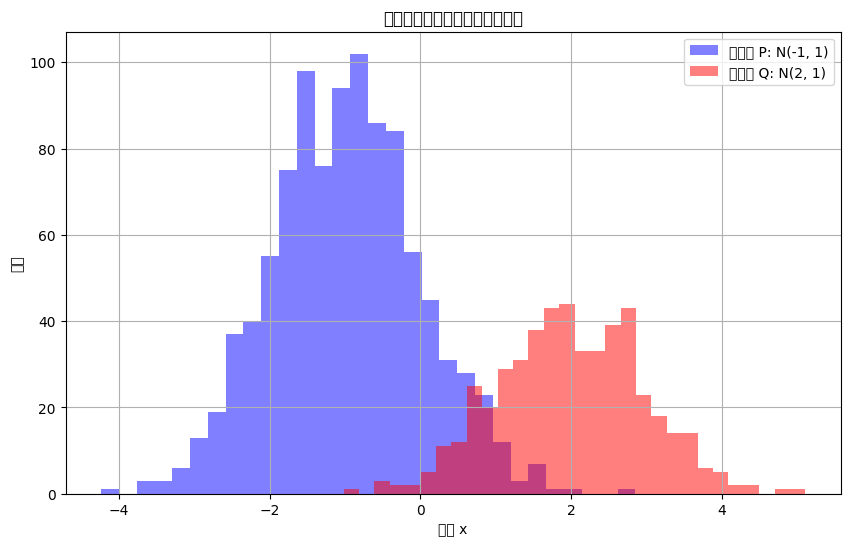

In [6]:
#5.2 编程题
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. 人工数据集构造
np.random.seed(42)

# 训练集 P：从 N(-1, 1) 采样
n_train = 1000
X_train = np.random.normal(-1, 1, n_train)
epsilon_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train + epsilon_train

# 测试集 Q：从 N(2, 1) 采样
n_test = 500
X_test = np.random.normal(2, 1, n_test)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test + epsilon_test

# 可视化数据分布
plt.figure(figsize=(10, 6))
plt.hist(X_train, bins=30, alpha=0.5, label='训练集 P: N(-1, 1)', color='blue')
plt.hist(X_test, bins=30, alpha=0.5, label='测试集 Q: N(2, 1)', color='red')
plt.xlabel('特征 x')
plt.ylabel('频率')
plt.title('训练集与测试集的特征分布对比')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# 2. 基线模型：简单线性回归
def linear_regression(X, y):
    X_b = np.c_[np.ones(len(X)), X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

def predict(X, theta):
    X_b = np.c_[np.ones(len(X)), X]
    return X_b.dot(theta)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 在训练集上训练
theta_baseline = linear_regression(X_train, y_train)
y_pred_train = predict(X_train, theta_baseline)
y_pred_test = predict(X_test, theta_baseline)

print('=' * 60)
print('基线模型结果')
print('=' * 60)
print(f'训练集 MSE: {mse(y_train, y_pred_train):.4f}')
print(f'测试集 MSE: {mse(y_test, y_pred_test):.4f}')
print(f'模型参数: theta0 = {theta_baseline[0]:.4f}, theta1 = {theta_baseline[1]:.4f}')

基线模型结果
训练集 MSE: 0.0099
测试集 MSE: 0.0102
模型参数: theta0 = 0.0030, theta1 = 1.9959


In [8]:
# 3. 偏移校正：逻辑回归分类器
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.theta = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        X_b = np.c_[np.ones(len(X)), X]
        self.theta = np.zeros(X_b.shape[1])
        
        for _ in range(self.epochs):
            z = X_b.dot(self.theta)
            pred = self.sigmoid(z)
            gradient = X_b.T.dot(pred - y) / len(y)
            self.theta -= self.lr * gradient
    
    def predict_proba(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return self.sigmoid(X_b.dot(self.theta))

# 混合训练数据：训练集标记为0，测试集标记为1
X_mixed = np.concatenate([X_train, X_test])
y_mixed = np.concatenate([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归分类器
lr = LogisticRegression(lr=0.5, epochs=5000)
lr.fit(X_mixed, y_mixed)

# 预测每个训练样本属于测试集的概率 P(test|x)
p_test_given_x_train = lr.predict_proba(X_train)
p_train_given_x_train = 1 - p_test_given_x_train

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = p_test_given_x_train / p_train_given_x_train
weights = np.clip(weights, 0.01, 100)  # 防止权重过大或过小

print('\n' + '=' * 60)
print('权重计算结果')
print('=' * 60)
print(f'权重均值: {np.mean(weights):.4f}')
print(f'权重最小值: {np.min(weights):.4f}')
print(f'权重最大值: {np.max(weights):.4f}')


权重计算结果
权重均值: 0.3877
权重最小值: 0.0100
权重最大值: 100.0000


In [9]:
# 4. 加权模型训练：加权最小二乘法
def weighted_linear_regression(X, y, weights):
    X_b = np.c_[np.ones(len(X)), X]
    W = np.diag(weights)
    theta = np.linalg.inv(X_b.T.dot(W).dot(X_b)).dot(X_b.T).dot(W).dot(y)
    return theta

# 使用权重重新训练
theta_weighted = weighted_linear_regression(X_train, y_train, weights)
y_pred_train_weighted = predict(X_train, theta_weighted)
y_pred_test_weighted = predict(X_test, theta_weighted)

print('\n' + '=' * 60)
print('加权模型结果')
print('=' * 60)
print(f'训练集 MSE: {mse(y_train, y_pred_train_weighted):.4f}')
print(f'测试集 MSE: {mse(y_test, y_pred_test_weighted):.4f}')
print(f'模型参数: theta0 = {theta_weighted[0]:.4f}, theta1 = {theta_weighted[1]:.4f}')

# 对比校正前后的结果
print('\n' + '=' * 60)
print('校正前后对比')
print('=' * 60)
print(f'校正前测试集 MSE: {mse(y_test, y_pred_test):.4f}')
print(f'校正后测试集 MSE: {mse(y_test, y_pred_test_weighted):.4f}')
print(f'MSE 改善比例: {(mse(y_test, y_pred_test) - mse(y_test, y_pred_test_weighted)) / mse(y_test, y_pred_test) * 100:.2f}%')


加权模型结果
训练集 MSE: 0.0270
测试集 MSE: 0.0151
模型参数: theta0 = -0.0584, theta1 = 2.0534

校正前后对比
校正前测试集 MSE: 0.0102
校正后测试集 MSE: 0.0151
MSE 改善比例: -47.89%


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtoo

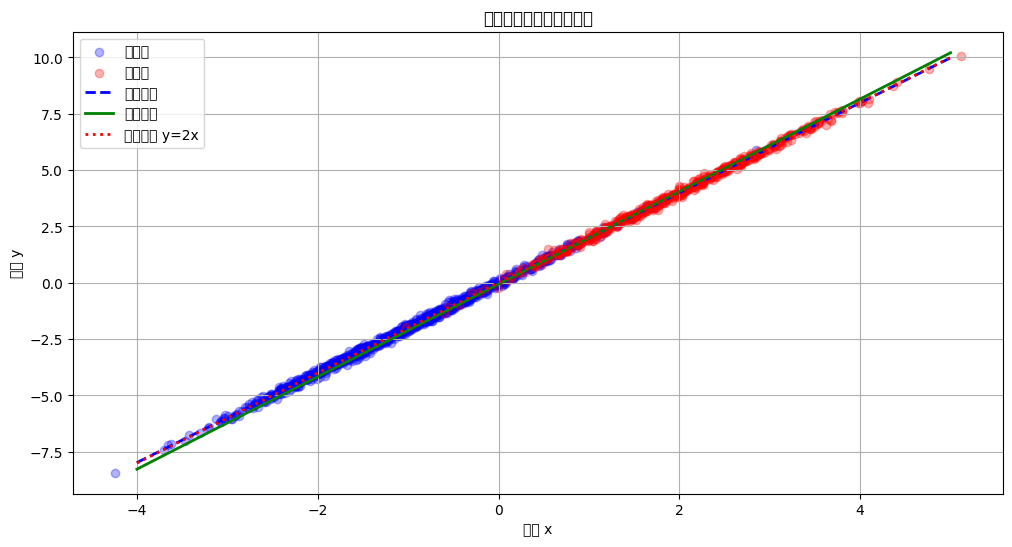

In [10]:
# 可视化校正效果
plt.figure(figsize=(12, 6))

# 绘制数据点
plt.scatter(X_train, y_train, alpha=0.3, label='训练集', color='blue')
plt.scatter(X_test, y_test, alpha=0.3, label='测试集', color='red')

# 绘制拟合直线
x_plot = np.linspace(-4, 5, 100)
y_plot_baseline = predict(x_plot, theta_baseline)
y_plot_weighted = predict(x_plot, theta_weighted)

plt.plot(x_plot, y_plot_baseline, label='基线模型', color='blue', linestyle='--', linewidth=2)
plt.plot(x_plot, y_plot_weighted, label='加权模型', color='green', linewidth=2)
plt.plot(x_plot, 2 * x_plot, label='真实模型 y=2x', color='red', linestyle=':', linewidth=2)

plt.xlabel('特征 x')
plt.ylabel('标签 y')
plt.title('协变量偏移校正效果对比')
plt.legend()
plt.grid(True)
plt.show()